# Deutsches Zentrum Data Analysis Project

## Project Overview

This project analyzes student registration and marketing performance data from **Deutsches Zentrum**, a German language center, to evaluate the impact of operational improvements implemented between the **Pre-Implementation** and **Post-Implementation** periods.

The project includes:

- Data Cleaning
- Exploratory Data Analysis (EDA)
- Student Growth Analysis
- Monthly Registration Trend Analysis
- Conversion Rate Analysis
- Marketing Channel Analysis
- Course Level Distribution Analysis
- Time Slot Analysis
- Business Insights

### Tools & Technologies

- Python
- Pandas
- Matplotlib
- Seaborn
- Microsoft Excel
- SQL Server
- Power BI

## Import Libraries

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Data Cleaning

## Load Datasets

In [6]:
students = pd.read_csv("students_raw.csv")
monthly = pd.read_csv("monthly_performance_raw.csv")

## Dataset Overview

In [7]:
students.head()

,Student_ID,Period,Registration_Date,Time_Slot,Level,Retention_Flag,Status,Feedback_Score,Attendance_Rate,Marketing_Channel
0,1001.0,Before,10.4.2023,10:00,A1+,Yes,Confirmed,3.0,0.8,Messenger
1,1002.0,Before,13.4.2023,10:00,A2,No,Confirmed,1.0,0.2,Instagram
2,1003.0,Before,13.4.2023,16:00,A2,No,Confirmed,1.0,0.3,Instagram
3,1004.0,Before,15.4.2023,10:00,B1,No,Cancelled,4.0,0.7,WhatsApp
4,1005.0,Before,18.4.2023,19:00,A1+,Yes,Confirmed,2.0,0.7,WhatsApp


In [8]:
students.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1302 entries, 0 to 1301
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Student_ID         651 non-null    float64
 1   Period             651 non-null    object 
 2   Registration_Date  651 non-null    object 
 3   Time_Slot          651 non-null    object 
 4   Level              651 non-null    object 
 5   Retention_Flag     965 non-null    object 
 6   Status             651 non-null    object 
 7   Feedback_Score     651 non-null    float64
 8   Attendance_Rate    651 non-null    float64
 9   Marketing_Channel  651 non-null    object 
dtypes: float64(3), object(7)
memory usage: 101.8+ KB


In [9]:
students.describe(include='all')

,Student_ID,Period,Registration_Date,Time_Slot,Level,Retention_Flag,Status,Feedback_Score,Attendance_Rate,Marketing_Channel
count,651.000000,651,651,651,651,965,651,651.000000,651.000000,651
unique,NaN,2,198,7,14,2,2,NaN,NaN,3
top,NaN,After,26.06.2024,19:00,A1,No,Confirmed,NaN,NaN,WhatsApp
freq,NaN,447,13,234,281,625,558,NaN,NaN,315
mean,1326.000000,NaN,NaN,NaN,NaN,NaN,NaN,3.603687,0.681720,NaN
std,188.071795,NaN,NaN,NaN,NaN,NaN,NaN,1.107840,0.226113,NaN
min,1001.000000,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,0.100000,NaN
25%,1163.500000,NaN,NaN,NaN,NaN,NaN,NaN,3.000000,0.500000,NaN
50%,1326.000000,NaN,NaN,NaN,NaN,NaN,NaN,4.000000,0.700000,NaN
75%,1488.500000,NaN,NaN,NaN,NaN,NaN,NaN,4.000000,0.800000,NaN


## Check Missing Values

In [10]:
students.isnull().sum()

,0
Student_ID,651
Period,651
Registration_Date,651
Time_Slot,651
Level,651
Retention_Flag,337
Status,651
Feedback_Score,651
Attendance_Rate,651
Marketing_Channel,651


## Remove Empty Rows

In [12]:
students = students.dropna(how='all')
students = students.dropna(subset=['Student_ID'])

In [13]:
students.shape

(651, 10)

## Check Duplicate Rows

In [14]:
students.duplicated().sum()

np.int64(0)

In [15]:
students = students.drop_duplicates()

In [16]:
students['Student_ID'] = students['Student_ID'].astype(int)

In [17]:
students.info()

<class 'pandas.core.frame.DataFrame'>
Index: 651 entries, 0 to 650
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Student_ID         651 non-null    int64  
 1   Period             651 non-null    object 
 2   Registration_Date  651 non-null    object 
 3   Time_Slot          651 non-null    object 
 4   Level              651 non-null    object 
 5   Retention_Flag     651 non-null    object 
 6   Status             651 non-null    object 
 7   Feedback_Score     651 non-null    float64
 8   Attendance_Rate    651 non-null    float64
 9   Marketing_Channel  651 non-null    object 
dtypes: float64(2), int64(1), object(7)
memory usage: 55.9+ KB


## Handle Invalid Dates

In [18]:
invalid_dates = pd.to_datetime(
    students['Registration_Date'],
    dayfirst=True,
    format='mixed',
    errors='coerce'
).isna()

students.loc[
    invalid_dates,
    ['Student_ID', 'Registration_Date']
]

,Student_ID,Registration_Date
77,1078,3.7.20231


In [25]:
students.loc[
    students['Student_ID'] == 1078,
    'Registration_Date'
] = '3.7.2023'

In [26]:
students['Registration_Date'] = pd.to_datetime(
    students['Registration_Date'],
    dayfirst=True
)

In [27]:
students.info()

<class 'pandas.core.frame.DataFrame'>
Index: 651 entries, 0 to 650
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Student_ID         651 non-null    int64         
 1   Period             651 non-null    object        
 2   Registration_Date  651 non-null    datetime64[ns]
 3   Time_Slot          651 non-null    object        
 4   Level              651 non-null    object        
 5   Retention_Flag     651 non-null    object        
 6   Status             651 non-null    object        
 7   Feedback_Score     651 non-null    float64       
 8   Attendance_Rate    651 non-null    float64       
 9   Marketing_Channel  651 non-null    object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(6)
memory usage: 55.9+ KB


## Standardize Period Names

In [28]:
students['Period'] = students['Period'].replace({
    'Before': 'Pre-Implementation',
    'After': 'Post-Implementation'
})

## Clean Level Names

In [29]:
students['Level'] = students['Level'].str.strip()

students['Level'] = students['Level'].str.upper()

students['Level'] = students['Level'].replace({
    'A1+': 'A1',
    'A2+': 'A2',
    'B1+': 'B1'
})

In [30]:
students['Level'].value_counts()

,count
Level,
A1,452
A2,116
B1,62
B2,21


## Standardize Time Slots

In [31]:
students['Time_Slot'] = students['Time_Slot'].replace({
    '10-1': '10:00',
    '11:00': '10:00',
    '17:00': '16:00'
})

In [32]:
students['Time_Slot'].value_counts()

,count
Time_Slot,
19:00,234
10:00,210
16:00,142
13:00,65


## Create Additional Features

In [33]:
students['Month'] = students['Registration_Date'].dt.strftime('%b')

In [34]:
students['Month_Number'] = students['Registration_Date'].dt.month

## Calculate Conversion Rate

In [35]:
monthly['Conversion_Rate'] = (
    (monthly['Registrations'] / monthly['Leads']) * 100
).round(2)

In [36]:
monthly.head()

,Month,Year,Leads,Registrations,Conversion_Rate
0,Apr,2023,131,16,12.21
1,May,2023,402,32,7.96
2,Jun,2023,344,29,8.43
3,Jul,2023,566,65,11.48
4,Aug,2023,543,62,11.42


# Data Cleaning Summary

The dataset was cleaned and standardized through the following steps:

- Removed empty rows.
- Removed invalid records.
- Verified duplicate records.
- Corrected invalid registration dates.
- Converted Student_ID to integer.
- Converted Registration_Date to datetime format.
- Standardized implementation period names.
- Merged course levels (A1+, A2+, B1+).
- Standardized course time slots.
- Created Month and Month_Number features.
- Calculated monthly conversion rate.

# Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) was conducted to understand student registration trends, evaluate the impact of operational improvements, and identify key business insights that support data-driven decision making.

## Student Growth Analysis

In [37]:
student_growth = (
    students.groupby('Period')['Student_ID']
    .count()
    .reset_index(name='Total_Students')
)

student_growth

,Period,Total_Students
0,Post-Implementation,447
1,Pre-Implementation,204


In [38]:
pre_students = student_growth.loc[
    student_growth['Period'] == 'Pre-Implementation',
    'Total_Students'
].values[0]

post_students = student_growth.loc[
    student_growth['Period'] == 'Post-Implementation',
    'Total_Students'
].values[0]

growth_rate = (
    (post_students - pre_students)
    / pre_students
) * 100

print(f"Pre-Implementation Students : {pre_students}")
print(f"Post-Implementation Students: {post_students}")
print(f"Growth Rate: {growth_rate:.2f}%")

Pre-Implementation Students : 204
Post-Implementation Students: 447
Growth Rate: 119.12%


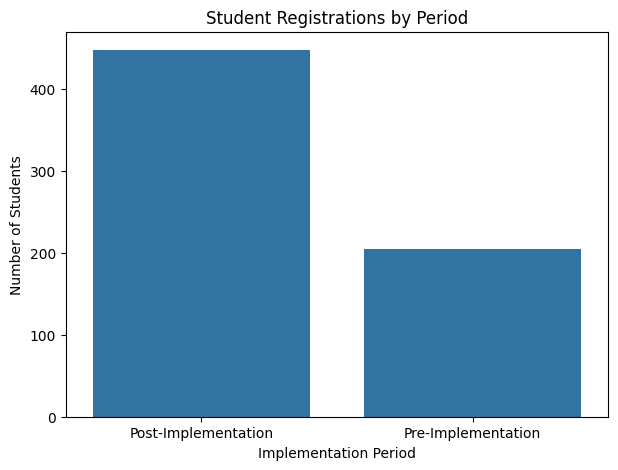

In [39]:
plt.figure(figsize=(7,5))

sns.barplot(
    data=student_growth,
    x='Period',
    y='Total_Students'
)

plt.title("Student Registrations by Period")
plt.xlabel("Implementation Period")
plt.ylabel("Number of Students")

plt.show()

### Business Insight

Student registrations increased from **204** during the Pre-Implementation period to **447** after the implementation of operational improvements.

This represents a **119.12% growth**, indicating a substantial improvement in student acquisition and overall enrollment performance.

## Monthly Registration Trend

In [40]:
monthly_registrations = (
    students.groupby(['Period', 'Month_Number'])['Student_ID']
    .count()
    .reset_index(name='Registrations')
)

monthly_registrations

,Period,Month_Number,Registrations
0,Post-Implementation,4,58
1,Post-Implementation,5,58
2,Post-Implementation,6,99
3,Post-Implementation,7,129
4,Post-Implementation,8,103
5,Pre-Implementation,4,16
6,Pre-Implementation,5,32
7,Pre-Implementation,6,29
8,Pre-Implementation,7,65
9,Pre-Implementation,8,62


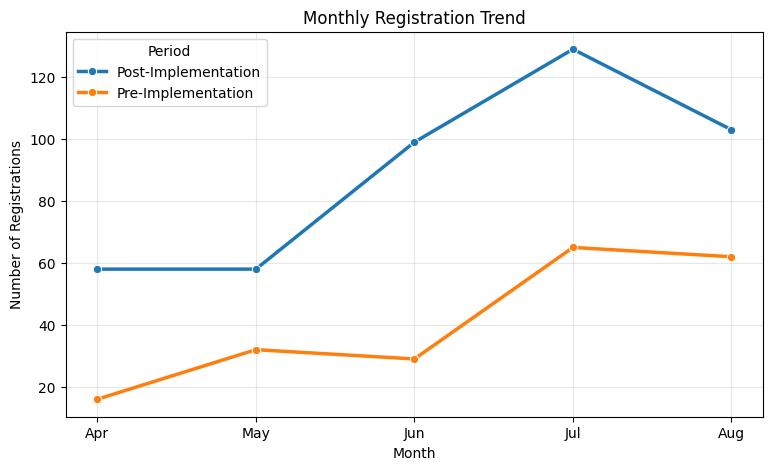

In [41]:
plt.figure(figsize=(9,5))

sns.lineplot(
    data=monthly_registrations,
    x='Month_Number',
    y='Registrations',
    hue='Period',
    marker='o',
    linewidth=2.5
)

plt.title('Monthly Registration Trend')
plt.xlabel('Month')
plt.ylabel('Number of Registrations')

plt.xticks([4,5,6,7,8], ['Apr','May','Jun','Jul','Aug'])

plt.grid(alpha=0.3)

plt.show()

### Business Insight

Student registrations increased consistently across all months during the Post-Implementation period.

The highest registration volume was recorded in **July 2024**, indicating the strongest enrollment performance after the implemented operational improvements.

The trend also demonstrates that the growth was sustainable rather than limited to a single month.

## Conversion Rate Analysis

In [43]:
monthly

,Month,Year,Leads,Registrations,Conversion_Rate
0,Apr,2023,131,16,12.21
1,May,2023,402,32,7.96
2,Jun,2023,344,29,8.43
3,Jul,2023,566,65,11.48
4,Aug,2023,543,62,11.42
5,Apr,2024,414,58,14.01
6,May,2024,346,59,17.05
7,Jun,2024,504,99,19.64
8,Jul,2024,852,128,15.02
9,Aug,2024,465,103,22.15


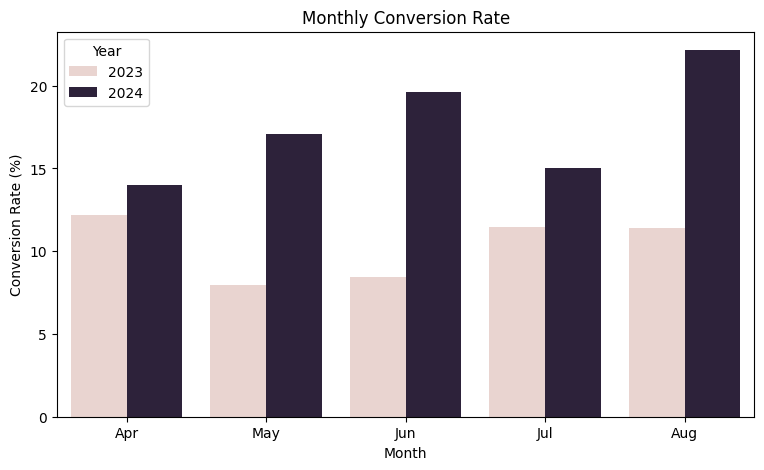

In [44]:
plt.figure(figsize=(9,5))

sns.barplot(
    data=monthly,
    x='Month',
    y='Conversion_Rate',
    hue='Year'
)

plt.title('Monthly Conversion Rate')
plt.xlabel('Month')
plt.ylabel('Conversion Rate (%)')

plt.show()

In [45]:
yearly_conversion = (
    monthly
    .groupby('Year')
    .agg({
        'Leads': 'sum',
        'Registrations': 'sum'
    })
)

yearly_conversion['Conversion_Rate'] = (
    (yearly_conversion['Registrations'] /
     yearly_conversion['Leads']) * 100
).round(2)

yearly_conversion

,Leads,Registrations,Conversion_Rate
Year,,,
2023,1986,204,10.27
2024,2581,447,17.32


### Business Insight

Although the total number of leads increased by approximately **30%**, registrations increased by more than **119%**.

As a result, the overall conversion rate improved from **10.27%** in 2023 to **17.32%** in 2024.

This indicates that operational improvements enhanced not only lead generation but also the effectiveness of converting prospective students into actual registrations.

## Marketing Channel Analysis

In [46]:
marketing_distribution = (
    students['Marketing_Channel']
    .value_counts()
    .reset_index()
)

marketing_distribution.columns = [
    'Marketing_Channel',
    'Students'
]

marketing_distribution

,Marketing_Channel,Students
0,WhatsApp,315
1,Messenger,236
2,Instagram,100


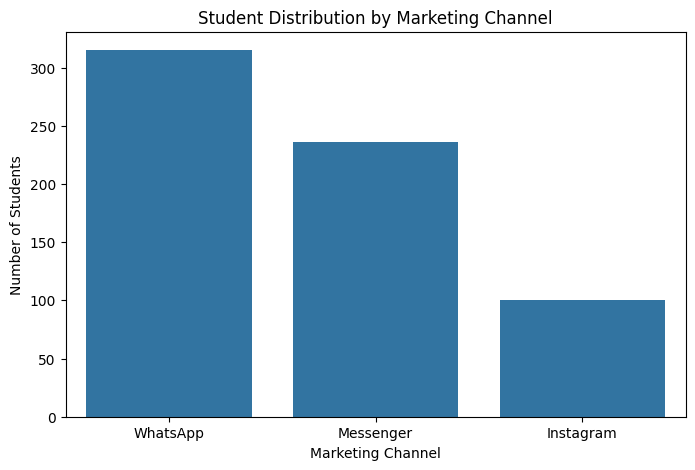

In [47]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=marketing_distribution,
    x='Marketing_Channel',
    y='Students'
)

plt.title("Student Distribution by Marketing Channel")
plt.xlabel("Marketing Channel")
plt.ylabel("Number of Students")

plt.show()

In [49]:
marketing_period = pd.crosstab(
    students['Marketing_Channel'],
    students['Period']
)

marketing_period

Period,Post-Implementation,Pre-Implementation
Marketing_Channel,,
Instagram,74,26
Messenger,166,70
WhatsApp,207,108


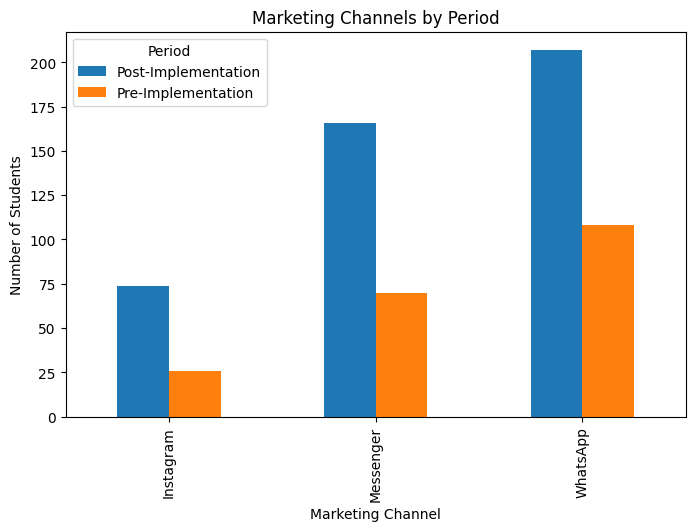

In [50]:
marketing_period.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Marketing Channels by Period")
plt.xlabel("Marketing Channel")
plt.ylabel("Number of Students")
plt.legend(title="Period")

plt.show()

In [51]:
marketing_conversion = (
    students.groupby('Marketing_Channel')
    .agg(
        Total_Students=('Student_ID','count'),
        Average_Feedback=('Feedback_Score','mean'),
        Average_Attendance=('Attendance_Rate','mean')
    )
    .round(2)
)

marketing_conversion

,Total_Students,Average_Feedback,Average_Attendance
Marketing_Channel,,,
Instagram,100,3.65,0.69
Messenger,236,3.58,0.69
WhatsApp,315,3.60,0.68


### Business Insight

WhatsApp remained the strongest student acquisition channel, generating the highest number of registrations.

Messenger also contributed significantly to student acquisition, while Instagram showed noticeable improvement after the operational changes.

The analysis suggests that maintaining investment in WhatsApp marketing while optimizing Instagram campaigns could further improve enrollment performance.

## Level Distribution Analysis

In [52]:
level_distribution = (
    students['Level']
    .value_counts()
    .reset_index()
)

level_distribution.columns = [
    'Level',
    'Students'
]

level_distribution

,Level,Students
0,A1,452
1,A2,116
2,B1,62
3,B2,21


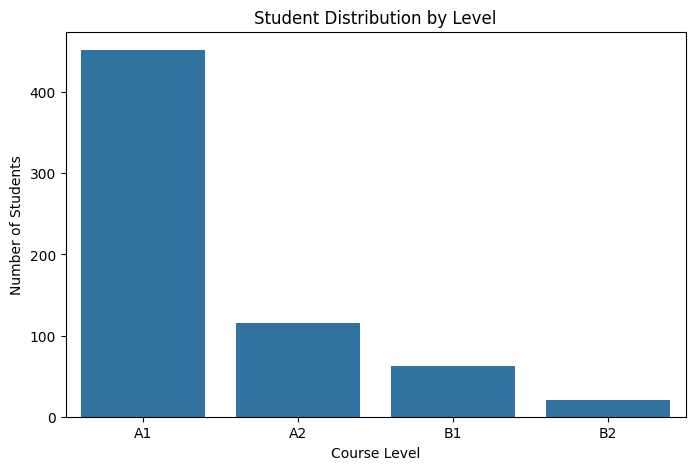

In [53]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=level_distribution,
    x='Level',
    y='Students'
)

plt.title("Student Distribution by Level")
plt.xlabel("Course Level")
plt.ylabel("Number of Students")

plt.show()

In [54]:
level_percentage = (
    students['Level']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .reset_index()
)

level_percentage.columns = [
    'Level',
    'Percentage'
]

level_percentage

,Level,Percentage
0,A1,69.43
1,A2,17.82
2,B1,9.52
3,B2,3.23


### Business Insight

A1 accounted for the largest share of student registrations, representing the primary entry point for new learners.

Enrollment gradually decreased across higher levels (A2, B1, and B2), reflecting the natural progression of students through the language learning journey.

This distribution is consistent with the expected enrollment funnel of most language centers.

## Time Slot Analysis

In [55]:
time_slot_distribution = (
    students['Time_Slot']
    .value_counts()
    .reset_index()
)

time_slot_distribution.columns = [
    'Time_Slot',
    'Students'
]

time_slot_distribution

,Time_Slot,Students
0,19:00,234
1,10:00,210
2,16:00,142
3,13:00,65


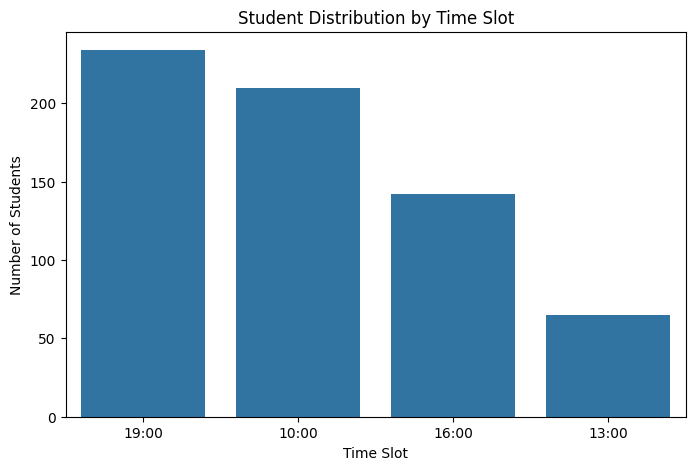

In [56]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=time_slot_distribution,
    x='Time_Slot',
    y='Students'
)

plt.title("Student Distribution by Time Slot")
plt.xlabel("Time Slot")
plt.ylabel("Number of Students")

plt.show()

In [57]:
time_slot_period = pd.crosstab(
    students['Time_Slot'],
    students['Period']
)

time_slot_period

Period,Post-Implementation,Pre-Implementation
Time_Slot,,
10:00,110,100
13:00,65,0
16:00,91,51
19:00,181,53


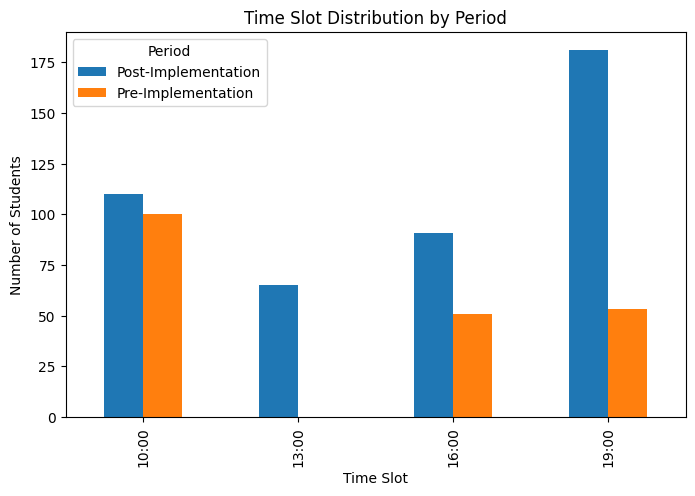

In [58]:
time_slot_period.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Time Slot Distribution by Period")
plt.xlabel("Time Slot")
plt.ylabel("Number of Students")
plt.legend(title="Period")

plt.show()

In [59]:
time_slot_percentage = (
    students['Time_Slot']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .reset_index()
)

time_slot_percentage.columns = [
    'Time_Slot',
    'Percentage'
]

time_slot_percentage

,Time_Slot,Percentage
0,19:00,35.94
1,10:00,32.26
2,16:00,21.81
3,13:00,9.98


### Business Insight

The **19:00** time slot was the most popular schedule, attracting the highest number of student registrations.

Additionally, the **13:00** time slot appeared almost exclusively during the Post-Implementation period, demonstrating the successful introduction and utilization of a new schedule that expanded enrollment capacity.

These findings suggest that optimizing course scheduling played an important role in supporting student growth.

# Key Findings

The analysis revealed several important business insights:

1. Student registrations increased by **119.12%** after the operational improvements.

2. Registration growth was consistent across all months, with **July 2024** recording the highest enrollment.

3. The overall conversion rate improved from **10.27%** to **17.32%**, indicating more effective conversion of leads into registrations.

4. WhatsApp remained the most effective marketing channel for attracting students, while Instagram experienced the highest relative growth.

5. A1 represented the largest proportion of registrations, reflecting the typical entry point for new language learners.

6. The 19:00 schedule was the most preferred time slot among students.

7. The introduction of the 13:00 time slot successfully expanded scheduling capacity and attracted additional registrations.

Overall, the implemented operational improvements had a measurable positive impact on student acquisition, marketing effectiveness, and enrollment performance.

# Export Cleaned Datasets

In [61]:
students.to_csv(
    'students_cleaned.csv',
    index=False
)

monthly.to_csv(
    'monthly_performance_cleaned.csv',
    index=False
)

In [62]:
from google.colab import files

files.download('students_cleaned.csv')
files.download('monthly_performance_cleaned.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>